# Phase 1: Data Collection & Assessment
**Objective:** Load the NASA CMAPSS FD001 dataset and inspect its structure.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path
current_dir = Path(os.getcwd())

In [3]:
#Define columns based on NASA documentation
operational_settings = ['setting_1', 'setting_2', 'setting_3']
sensors = [f'sensor_{i}' for i in range(1, 22)]
columns = ['engine_id', 'cycle'] + operational_settings + sensors

#Path finder 
current_dir = Path(os.getcwd())
data_path = current_dir.parent / "data" / "raw" / "train_FD001.txt"

if data_path.exists():
    train_df = pd.read_csv(data_path, sep=r'\s+', header=None, names=columns)
    print(" Data loaded successfully!")
    print(train_df.head())
else:
    print(f" Still can't find it at: {data_path}")
    #Show what folders ARE there to help debug
    print(f"Contents of {current_dir.parent}: {os.listdir(current_dir.parent)}")

 Data loaded successfully!
   engine_id  cycle  setting_1  setting_2  setting_3  sensor_1  sensor_2  \
0          1      1    -0.0007    -0.0004      100.0    518.67    641.82   
1          1      2     0.0019    -0.0003      100.0    518.67    642.15   
2          1      3    -0.0043     0.0003      100.0    518.67    642.35   
3          1      4     0.0007     0.0000      100.0    518.67    642.35   
4          1      5    -0.0019    -0.0002      100.0    518.67    642.37   

   sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  sensor_14  \
0   1589.70   1400.60     14.62  ...     521.66    2388.02    8138.62   
1   1591.82   1403.14     14.62  ...     522.28    2388.07    8131.49   
2   1587.99   1404.20     14.62  ...     522.42    2388.03    8133.23   
3   1582.79   1401.87     14.62  ...     522.86    2388.08    8133.83   
4   1582.85   1406.22     14.62  ...     522.19    2388.04    8133.80   

   sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  sensor_20  sensor_2

# Phase 2: Data Cleaning & Target Engineering
**Objective:** Handle missing values, drop flatline sensors (noise), and engineer our target variable: the 30-cycle risk window.

In [4]:
#Check for missing values (Should be 0 for this dataset)
print(f"Missing Values: {train_df.isnull().sum().sum()}")

# Check data types (everything should be int64 or float64)
print("\nData Types:")
print(train_df.dtypes.value_counts())

# Basic statistics to spot anomalies (e.g max values that make no physical sense)
display(train_df.describe())


#Engineer Target Variable: Remaining Useful Life (RUL)
rul = pd.DataFrame(train_df.groupby('engine_id')['cycle'].max()).reset_index()
rul.columns = ['engine_id', 'max_cycle']
train_df = train_df.merge(rul, on = ['engine_id'], how = 'left')


#Rul =  max cycle minus current cycle
train_df['RUL'] = train_df['max_cycle'] - train_df['cycle']
train_df.drop('max_cycle', axis =1, inplace= True)

# Create Binary label ( 1 if failure is within 30 cycles, 0 otherwise)
train_df['risk_label'] = np.where(train_df['RUL'] <= 30, 1, 0)

#Drop the useless sensors ( sensors with zero variance/flat lines)
sensors_std =train_df[sensors].std()
useless_sensors = sensors_std[sensors_std < 0.01].index.tolist()
print(f"\nDropping sensors with zero variance: {useless_sensors}")

train_df_clean = train_df.drop(columns= useless_sensors)
useful_sensors = [s for s in sensors if s not in useless_sensors]

print("Target engineered and noise removed")

Missing Values: 0

Data Types:
float64    22
int64       4
Name: count, dtype: int64


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,5.329200e-15,...,0.737553,0.071919,19.076176,0.037505,3.469531e-18,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400



Dropping sensors with zero variance: ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Target engineered and noise removed


# Phase 3: Exploratory Data Analysis (EDA)
**Objective:** Visualize feature correlations to verify which sensors are strong predictors of engine failure.

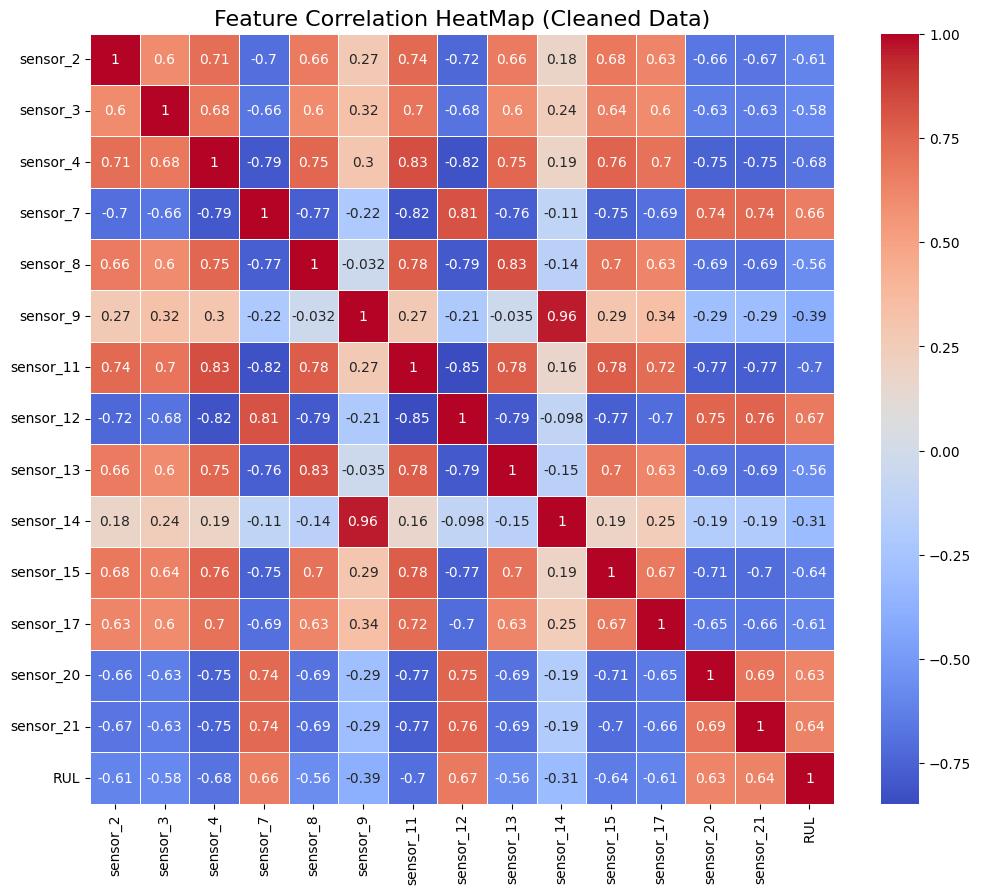

In [5]:
# Plot correlate heatMap

plt.figure(figsize = (12,10))

#correlate the remaining useful sensors against RUL
corr_matrix = train_df_clean[useful_sensors + ['RUL']].corr()

sns.heatmap(corr_matrix, annot =True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation HeatMap (Cleaned Data)', fontsize = 16)
plt.show()


**Objective:** Visualize how the top 4 most correlated sensors interact with each other and separate the "Healthy" states from the "Risk" states.

Top 4 most critical sensors: ['sensor_11', 'sensor_4', 'sensor_12', 'sensor_7']
Generating PairPlot...


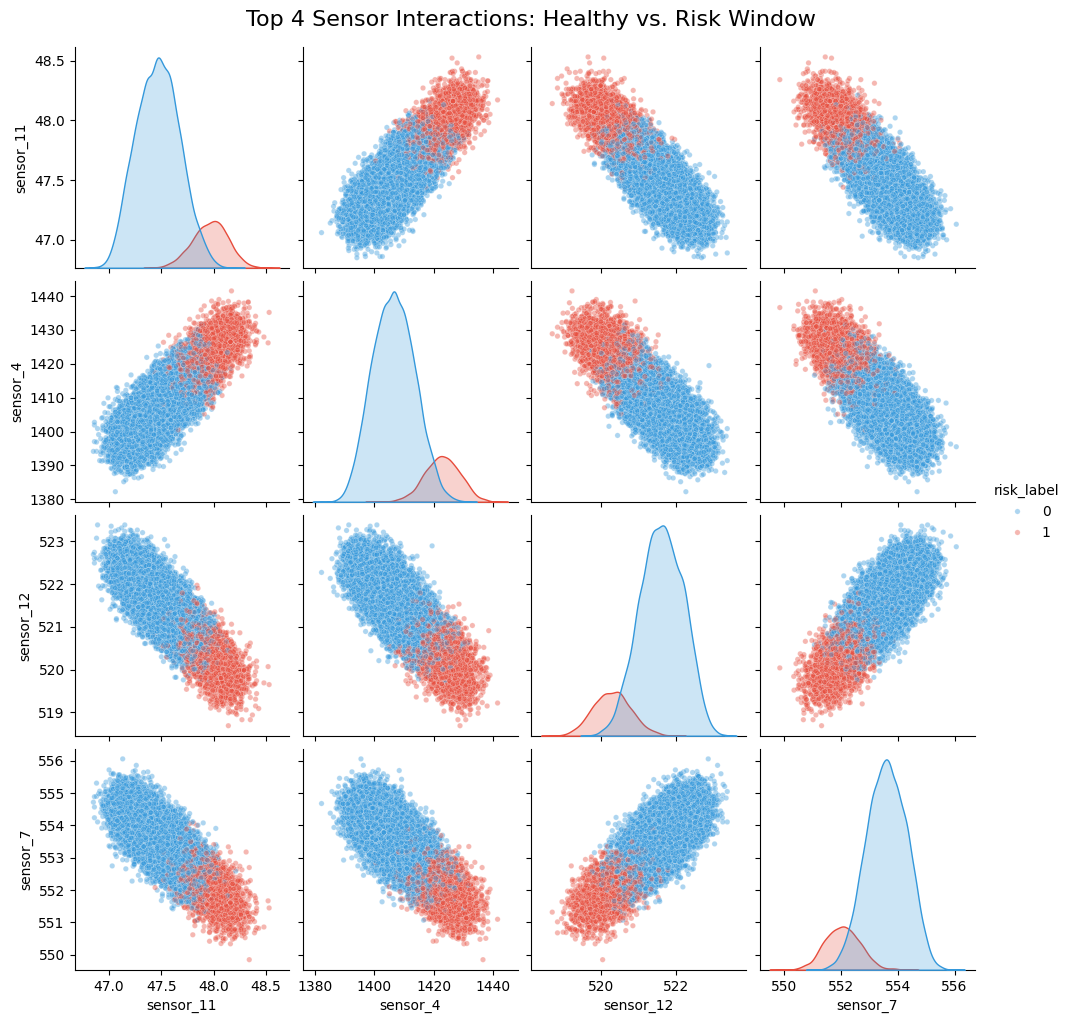

In [6]:
# Phase 3b: Advanced EDA - Feature Distributions
# 1. Automatically find the top 4 sensors most correlated with RUL 
top_4_sensors = corr_matrix['RUL'].drop('RUL').abs().nlargest(4).index.tolist()
print(f"Top 4 most critical sensors: {top_4_sensors}")

# 2. Select columns to plot
cols_to_plot = top_4_sensors + ['risk_label']

# 3. Create the PairPlot
print("Generating PairPlot...")
sns.pairplot(
    train_df_clean[cols_to_plot], 
    hue='risk_label', 
    palette={0: '#3498db', 1: '#e74c3c'}, # Blue for Healthy, Red for Risk
    plot_kws={'alpha': 0.4, 's': 15},     # alpha makes dots transparent
    diag_kind='kde'                       # Smooth distribution curves
)

plt.suptitle('Top 4 Sensor Interactions: Healthy vs. Risk Window', y=1.02, fontsize=16)
plt.show()

# Time-Series Degradation 
**Objective:** Visualize "what a failure looks like in real-time" by plotting the trajectory of our top sensors for a single engine over its entire lifespan.

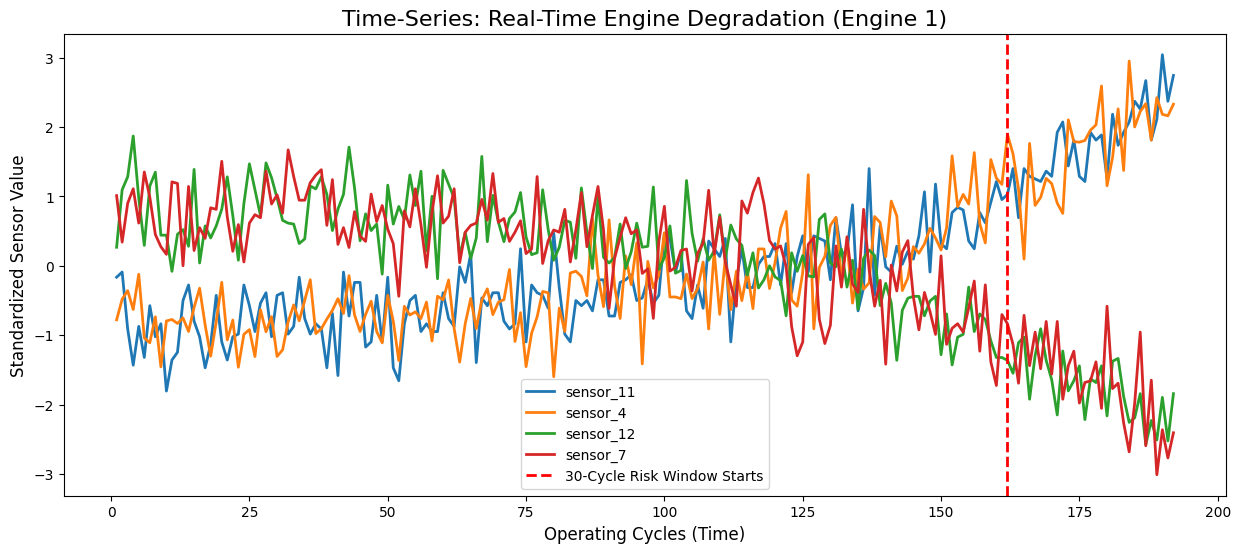

In [7]:
# Let's look at the lifecycle of Engine 1 using our Top 4 sensors
engine_1_data = train_df_clean[train_df_clean['engine_id'] == 1]

plt.figure(figsize=(15, 6))

# Plot each of the top 4 sensors
for sensor in top_4_sensors:
    # We use a secondary axis or normalize just for this plot if scales are wildly different, 
    # but for CMAPSS, standardizing them quickly for visualization helps:
    normalized_sensor = (engine_1_data[sensor] - engine_1_data[sensor].mean()) / engine_1_data[sensor].std()
    plt.plot(engine_1_data['cycle'], normalized_sensor, label=sensor, linewidth=2)

# Draw the Risk Window boundary
failure_cycle = engine_1_data['cycle'].max()
risk_start = failure_cycle - 30
plt.axvline(x=risk_start, color='red', linestyle='--', linewidth=2, label='30-Cycle Risk Window Starts')

plt.title('Time-Series: Real-Time Engine Degradation (Engine 1)', fontsize=16)
plt.xlabel('Operating Cycles (Time)', fontsize=12)
plt.ylabel('Standardized Sensor Value', fontsize=12)
plt.legend()
plt.show()

# Safety Limits & Outliers (Box Plots)
**Objective:** Establish visual "safety limits" by comparing the statistical distribution of sensor readings during normal operation versus the 30-cycle risk window.

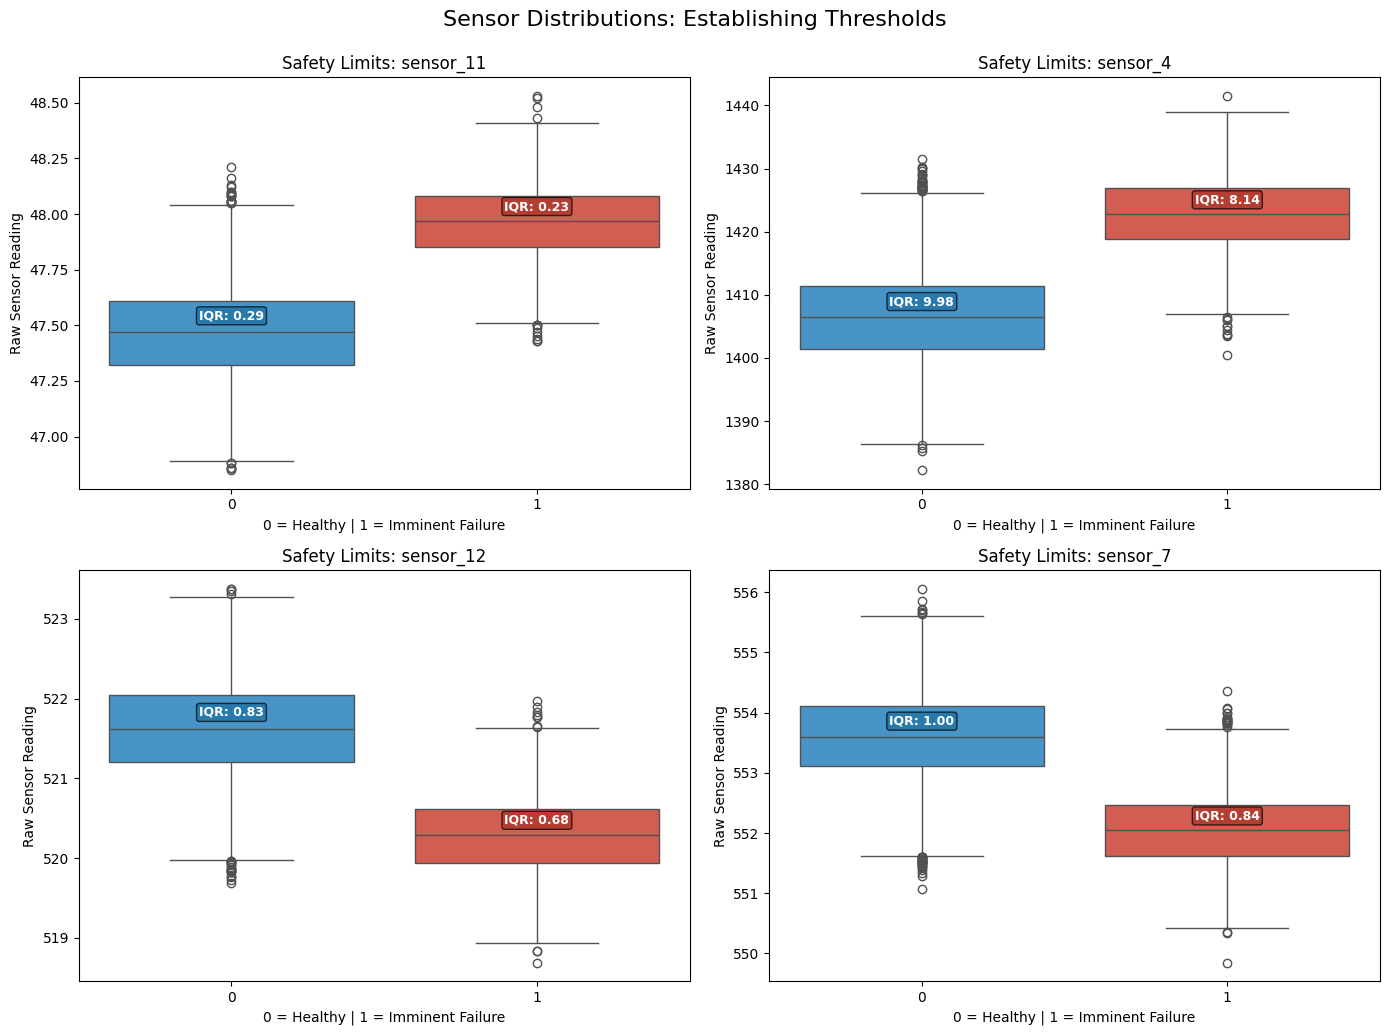

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, sensor in enumerate(top_4_sensors):
    sns.boxplot(
        x='risk_label', 
        y=sensor, 
        data=train_df_clean, 
        hue='risk_label',
        palette=['#3498db', '#e74c3c'],
        legend=False,
        ax=axes[i]
    )
    
    # --- Calculate and annotate IQR for each class ---
    for label, color in zip([0, 1], ['#1a6fa3', '#a93226']):
        subset = train_df_clean[train_df_clean['risk_label'] == label][sensor]
        q1 = subset.quantile(0.25)
        q3 = subset.quantile(0.75)
        iqr = q3 - q1
        median = subset.median()
        
        # Place IQR text just above the median line inside the box
        axes[i].text(
            label,                          # x position (0 or 1)
            median + (iqr * 0.15),          # y position: slightly above median
            f'IQR: {iqr:.2f}',
            ha='center', va='bottom',
            fontsize=9, fontweight='bold',
            color='white',
            bbox=dict(boxstyle='round,pad=0.2', facecolor=color, alpha=0.7)
        )

    axes[i].set_title(f'Safety Limits: {sensor}', fontsize=12)
    axes[i].set_xlabel('0 = Healthy | 1 = Imminent Failure')
    axes[i].set_ylabel('Raw Sensor Reading')

plt.tight_layout()
plt.suptitle('Sensor Distributions: Establishing Thresholds', y=1.03, fontsize=16)
plt.show()

# Phase 4a: Feature Scaling & Normalization
**Objective:** Compress raw sensor readings of vastly different magnitudes into a standardized [0, 1] range to ensure stable neural network weight optimization.

In [9]:
from sklearn.preprocessing import MinMaxScaler

#initi the scaler with explicit feature range
scaler = MinMaxScaler(feature_range=(0,1))

#only scale the sensor readings
train_df_scaled = train_df_clean.copy()
train_df_scaled[useful_sensors] = scaler.fit_transform(train_df_scaled[useful_sensors])

print("Data successfully scaled to [0, 1] range.")
display(train_df_scaled[['engine_id','cycle'] + top_4_sensors + ['risk_label']].head(3))


Data successfully scaled to [0, 1] range.


,engine_id,cycle,sensor_11,sensor_4,sensor_12,sensor_7,risk_label
0,1,1,0.369048,0.309757,0.633262,0.726248,0
1,1,2,0.380952,0.352633,0.765458,0.628019,0
2,1,3,0.250000,0.370527,0.795309,0.710145,0


# Phase 4b: Time-Series Windowing with Pre-Padding (3D Transformation)
**Objective:** Transform the 2D tabular data into 3D sliding windows `[Samples, Time Steps, Features]`. We utilize `pad_sequences` with `padding='pre'` to handle engines in the test set that have fewer cycles than our designated window size, ensuring the LSTM receives the most recent sensor data last.

In [10]:
from numpy.lib.stride_tricks import sliding_window_view

def create_sequence_with_padding(df, window_size, feature_cols, target_col):
    """
    Transforms 2D engine data into 3D tensors (Samples, Timesteps, Features).
    - Short engines (cycles < window_size): pre-padded with zeros using np.pad
    - Normal engines (cycles >= window_size): vectorized sliding window via sliding_window_view
    """
    
    # Ensure data is sorted so the window does not contain scrambled cycles
    df = df.sort_values(['engine_id', 'cycle'])

    X, y = [], []

    for _, group in df.groupby('engine_id'):
        data = group[feature_cols].values
        labels = group[target_col].values

        # 1. Handle short engines (Crucial for the test set)
        if len(data) < window_size:
            pad_width = window_size - len(data)
            padding_data = np.pad(data, ((pad_width, 0), (0, 0)), mode='constant')
            X.append(padding_data) 
            y.append(labels[-1]) 

        # 2. Handle normal engines: Vectorized sliding window
        else:
            windows = sliding_window_view(data, (window_size, data.shape[1]))
            # windows shape is initially (N, 1, window_size, features). Squeeze removes the dummy dimension.
            X.extend(np.squeeze(windows, axis=1))
            
            # Extract the corresponding labels (the label at the END of each window)
            y_windows = labels[window_size - 1:]
            y.extend(y_windows)

    return np.array(X), np.array(y)

# Define look-back window size
sequence_length = 50

# Execute the advanced transformation
X_train, y_train = create_sequence_with_padding(
    df=train_df_scaled,
    window_size=sequence_length,
    feature_cols=useful_sensors,
    target_col='risk_label'
)

print("  3D Tensor Transformation complete!")
print(f"X_train shape: {X_train.shape} -> (Samples, Time Steps, Features)")
print(f"y_train shape: {y_train.shape}      -> (Labels)")

  3D Tensor Transformation complete!
X_train shape: (15731, 50, 14) -> (Samples, Time Steps, Features)
y_train shape: (15731,)      -> (Labels)


# Save the results

In [12]:

#Create the 'processed' directory if it doesn't exist yet
os.makedirs('../data/processed', exist_ok=True)

# 2. Now save the files safely
np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/y_train.npy', y_train)

print("Tensors saved successfully to data/processed/")

Tensors saved successfully to data/processed/
